In [1]:
import xarray as xr
import numpy as np
from pathlib import Path
import gsw
from xarray import open_mfdataset, open_dataset
from matplotlib import pyplot as plt



# Utilities 
def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid

def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 100, 'x':100, 'z': -1},
    )

    if model == 'VIKING20X.L46-KFS003' and not nest:
        nest_part = 'ori_'

    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':100, 'X':100, 'z': -1}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo



In [2]:
V_grid = load_dataset_from_grid_type('V', (2007, 2015), nest = True, model = 'VIKING20X.L46-KFS003', delta_t = '1m', chunks={"time_counter" : None,"y": 20, "x": 300})

In [4]:
indices = (np.abs(V_grid.nav_lat - 26.5) ).argmin(dim = 'y').compute()

In [14]:
indices.mean()

<xarray.DataArray 'nav_lat' ()>
array(1273.71381032)

In [18]:
V_grid_loaded = V_grid.isel(y = 1274).isel(x = slice(400,2000)).vomecrty.compute()

In [26]:
mask_mesh, mask_glo = load_masks(nest = True, model = 'VIKING20X.L46-KFS003')

mask_mesh_loaded = mask_mesh.isel(y = 1274).isel(x = slice(400,2000)).tmask.compute()

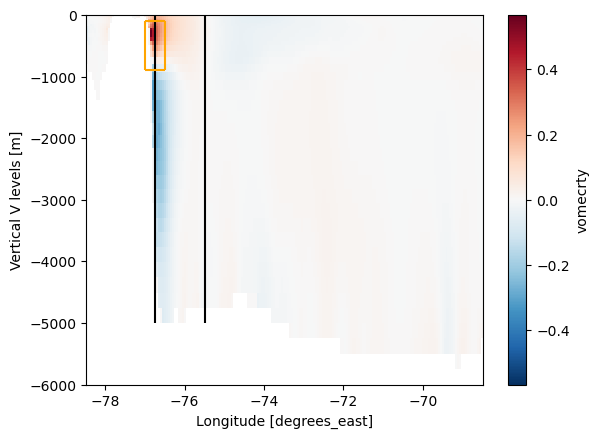

In [91]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

V_grid_loaded.mean('time_counter').where(mask_mesh_loaded.rename({'z': 'depthv'}) == 1).assign_coords(z = -V_grid_loaded.depthv).isel(x = slice(0,200)).plot(x = 'nav_lon', y = 'z', ax = ax)

ax.vlines(-75.5,-5000,0, color = 'black')
ax.vlines(-76.74,-5000,0, color = 'black')


ax.vlines(-77,-900,-100, color = 'orange')
ax.vlines(-76.5,-900,-100, color = 'orange')
ax.hlines(-900, -77, -76.5, color = 'orange')
ax.hlines(-100, -77, -76.5, color = 'orange')

In [76]:
mask_mesh.e3v_0.isel(y = 1274).isel(x = slice(400,2000))

<xarray.DataArray 'e3v_0' (z: 46, x: 1600)>
dask.array<getitem, shape=(46, 1600), dtype=float64, chunksize=(46, 100), chunktype=numpy.ndarray>
Dimensions without coordinates: z, x

In [83]:
dx = mask_mesh.e1v.isel(y = 1274).isel(x = slice(400,2000))
dz = mask_mesh.e3v_0.isel(y = 1274).isel(x = slice(400,2000)).rename({'z':'depthv'})
volume_transport = V_grid_loaded * dx * dz

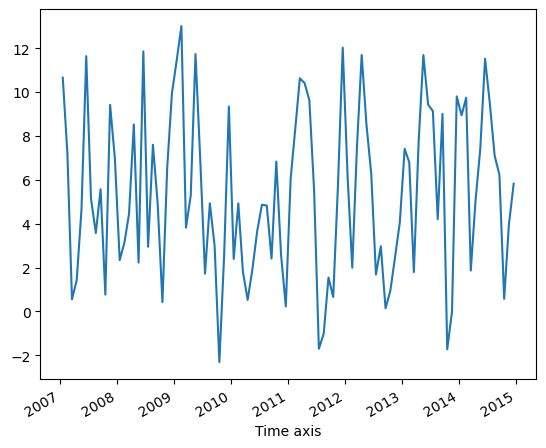

In [89]:
(
    volume_transport.set_index(x = 'nav_lon').sel(x = slice(-77,-76.5), depthv = slice(0, 1000)).sum(['depthv', 'x']) / 1e6
).plot()

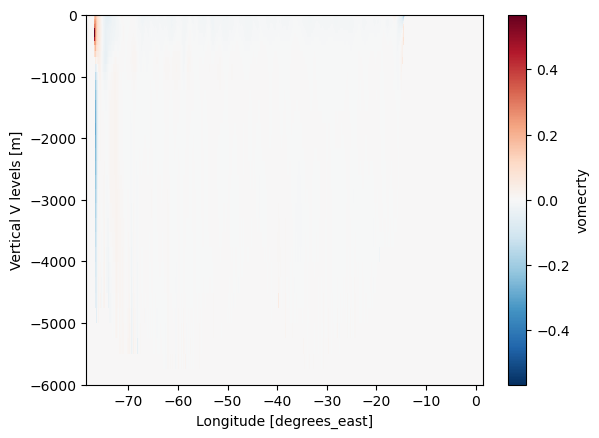

In [24]:
V_grid_loaded.mean('time_counter').assign_coords(z = - V_grid_loaded.depthv).plot(x = 'nav_lon', y = 'z')

In [5]:
target_latitude_ds = V_grid.isel(y = indices)

In [6]:
v_velocities = target_latitude_ds.mean(dim = 'time_counter').isel(x = slice(400,2000)).vomecrty

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='16GB')
# print the dashboard link
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 59.60 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36811,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 4
Started: Just now,Total memory: 59.60 GiB
Comm: tcp://127.0.0.1:39119,Total threads: 1
Dashboard: http://127.0.0.1:46763/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:43281,


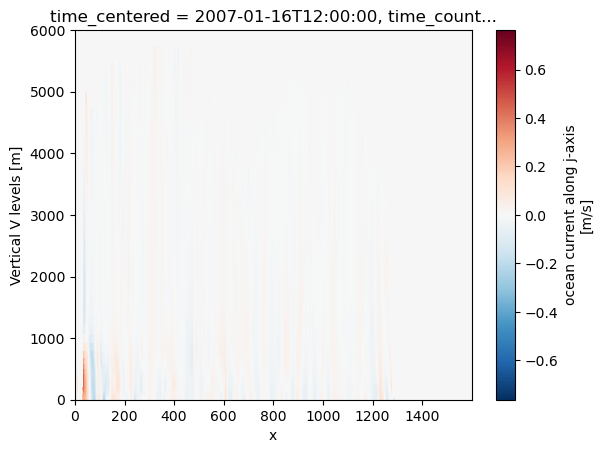

In [12]:
target_latitude_ds.isel(time_counter = 0).isel(x = slice(400,2000)).vomecrty.plot()

In [2]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster
import os

cluster = SLURMCluster(
    cores=1,
    # processes=1,
    memory="12GB",
    shebang='#!/usr/bin/env bash',
    queue="base",
    walltime="02:40:00",
    local_directory='/tmp',
    death_timeout="15s",
    interface="ib0",
    log_directory=f'/gxfs_work/geomar/smomw507/geomar/rapid-geostrophic-reconstruction/logs',
    )

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.18.4.106:8787/status,
Dashboard: http://172.18.4.106:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.106:36835,Workers: 0
Dashboard: http://172.18.4.106:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
cluster.scale(400)

In [3]:
cluster

Dashboard: http://172.18.4.106:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.18.4.106:36835,Workers: 0
Dashboard: http://172.18.4.106:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
from dask.distributed import Client
# client = Client(n_workers=6, threads_per_worker=1, memory_limit='8GB')

client = Client('tcp://10.0.4.105:8786')

In [4]:

import numpy as np
import xarray as xr
from pathlib import Path


cycle_number = 2
smoothing_days = 90
time_smooth = f'{smoothing_days}D'

dask_url = 'tcp://10.0.4.105:8786'

if cycle_number == 1:
    suffix = '1st_7024' 
    model = 'VIKING20X.L46-KFS003'
    model_years_selector = (1970, 2024)
elif cycle_number == 2:
    suffix = '2nd_5824'
    model = 'VIKING20X.L46-KFS003-2nd'
    model_years_selector = (1958, 2024)
elif cycle_number == 3:
    suffix = '3rd_5824'
    model = 'VIKING20X.L46-KFS003-3rd'
    model_years_selector = (1958, 2024)
elif cycle_number == 4:
    suffix = '4th_5824'
    model = 'VIKING20X.L46-KFS003-4th'
    model_years_selector = (1958, 2024)
elif cycle_number == 5:
    suffix = '5th_5824'
    model = 'VIKING20X.L46-KFS003-5th'
    model_years_selector = (1958, 2024)
elif cycle_number == 6:
    suffix = '6th_5824'
    model = 'VIKING20X.L46-KFS003-6th'
    model_years_selector = (1958, 2024)
else:
    assert False, 'Cycle number not recognized'


dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/paperdraft/')


In [5]:
V_grid = load_dataset_from_grid_type('V', model_years_selector, nest = True, model = model, delta_t = '1d', chunks={"time_counter" : 12,"y": None, "x": None})



In [6]:

mask_mesh, mask_glo = load_masks(nest = True, model = model)



In [7]:



V_grid_loaded = V_grid.isel(y = 1274).isel(x = slice(400,2000)).vomecrty
dx = mask_mesh.e1v.isel(y = 1274).isel(x = slice(400,2000))
dz = mask_mesh.e3v_0.isel(y = 1274).isel(x = slice(400,2000)).rename({'z':'depthv'})
volume_transport = V_grid_loaded * dx * dz



/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


In [8]:

transport = (
    volume_transport.set_index(x = 'nav_lon').sel(x = slice(-77,-76.5), depthv = slice(0, 1000)).sum(['depthv', 'x']) / 1e6
)


In [10]:


transport.to_netcdf(f'../rapid-geostrophic-reconstruction/datasets/antilles_current/antilles_current_KFS003-{suffix}.nc')


2025-03-28 12:38:41,783 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
